# SAM2 (Hiera-L) Zero-Shot Baseline — Full Pipeline
**Project:** MoE-RenalSAM-CG | **Institution:** BRAC University  
**Purpose:** Evaluate the zero-shot segmentation capability of the Segment Anything Model 2 (SAM2) on the out-of-distribution RenSeg-KidneyCT dataset.

This notebook implements:
1. Loading the frozen SAM2 Hiera-L checkpoint
2. Running Automatic Mask Generation (AMG) over the full test set
3. Oracle mask selection against expert ground truth
4. Per-class metric computation (Dice, IoU, HD95, Precision, Recall, F1)
5. Publication-quality visualizations (bar charts, radar plots, qualitative grids)

> **Key Thesis:** While SAM2 introduces video-segmentation capabilities and a hierarchical architecture, its zero-shot performance on medical imaging still suffers from a Generalization Gap, producing class-agnostic masks that do not target specific renal pathologies without fine-tuning.

In [1]:
!pip install -q opencv-python matplotlib seaborn tqdm pandas scipy

## 1. Imports & Configuration

In [2]:
import os, sys, warnings, random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
from scipy.ndimage import distance_transform_edt

import torch

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.autocast(device_type="cuda", dtype=torch.bfloat16).__enter__()

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'

print(f'Device: {DEVICE}')

# Absolute fallback path
PROJECT_ROOT = Path(r'/Users/ashrafulkabir/Desktop/project reseg/MoE-RenalSAM-CG')
if not PROJECT_ROOT.exists():
    PROJECT_ROOT = Path(os.getcwd()).parent

# Setup SAM2 path
SAM2_ROOT = PROJECT_ROOT / 'segment-anything-2'
sys.path.insert(0, str(SAM2_ROOT))

SAM2_CONFIG = 'configs/sam2.1/sam2.1_hiera_l.yaml'
SAM2_CKPT = PROJECT_ROOT / 'weights' / 'sam2_hiera_large.pt'
RESULTS_DIR = PROJECT_ROOT / 'data' / 'processed' / 'reports' / 'baselines_zeroshot'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CLASSES = ['Normal', 'Tumor', 'Stone']
print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'SAM2 checkpoint exists: {SAM2_CKPT.exists()}')

Device: cuda
PROJECT_ROOT: D:\MoE-RenalSAM-CG\MoE-RenalSAM-CG
SAM2 checkpoint exists: True


## 2. Load SAM2 (Hiera-L) — Frozen, No Fine-Tuning

In [3]:
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

sam2_model = build_sam2(
    config_file=SAM2_CONFIG,
    ckpt_path=str(SAM2_CKPT),
    device=DEVICE,
    mode='eval'
)

# Freeze all parameters (strict zero-shot)
for p in sam2_model.parameters():
    p.requires_grad = False

total_params = sum(p.numel() for p in sam2_model.parameters())
print(f'SAM2 Hiera-L loaded | Total params: {total_params:,} | All frozen (zero-shot)')

mask_generator = SAM2AutomaticMaskGenerator(
    model=sam2_model,
    points_per_side=32,
    points_per_batch=64,
    pred_iou_thresh=0.86,
    stability_score_thresh=0.92,
    stability_score_offset=1.0,
    crop_n_layers=1,
    box_nms_thresh=0.7,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=100,
    use_m2m=True,
)
print('SAM2AutomaticMaskGenerator ready.')

SAM2 Hiera-L loaded | Total params: 224,446,642 | All frozen (zero-shot)
SAM2AutomaticMaskGenerator ready.


## 3. Data Manifest

In [4]:
manifest_csv = PROJECT_ROOT / 'data' / 'splits' / 'test_manifest.csv'
if not manifest_csv.exists():
    raise FileNotFoundError(f"Manifest not found: {manifest_csv}")

test_df = pd.read_csv(manifest_csv)
if 'class_name' in test_df.columns:
    test_df = test_df.rename(columns={'class_name': 'class'})

print(f'Total Test Images: {len(test_df)}')
display(test_df['class'].value_counts())

Total Test Images: 1749


class
Normal    1016
Tumor      457
Stone      276
Name: count, dtype: int64

## 4. Metric Evaluation Framework

In [5]:
def compute_metrics(pred: np.ndarray, gt: np.ndarray, pixel_spacing_mm=0.5):
    p = (pred > 0).astype(bool).ravel()
    g = (gt > 0).astype(bool).ravel()
    
    if not p.any() and not g.any():
        return {'dice': 1.0, 'iou': 1.0, 'hd95': 0.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0}
    
    tp = np.logical_and(p, g).sum()
    fp = np.logical_and(p, ~g).sum()
    fn = np.logical_and(~p, g).sum()
    
    dice = (2 * tp) / (2 * tp + fp + fn + 1e-8)
    iou = tp / (tp + fp + fn + 1e-8)
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = (2 * precision * recall) / (precision + recall + 1e-8)
    
    pred_2d = (pred > 0)
    gt_2d = (gt > 0)
    if pred_2d.any() and gt_2d.any():
        dt_pred = distance_transform_edt(~pred_2d) * pixel_spacing_mm
        dt_gt = distance_transform_edt(~gt_2d) * pixel_spacing_mm
        hd95 = float(np.percentile(np.concatenate([dt_gt[pred_2d], dt_pred[gt_2d]]), 95))
    else:
        hd95 = float(np.sqrt(pred_2d.shape[0]**2 + pred_2d.shape[1]**2) * pixel_spacing_mm)
        
    return {
        'dice': round(float(dice), 4),
        'iou': round(float(iou), 4),
        'hd95': round(float(hd95), 4),
        'precision': round(float(precision), 4),
        'recall': round(float(recall), 4),
        'f1': round(float(f1), 4)
    }

print('Metric functions ready.')

Metric functions ready.


## 5. Zero-Shot Inference (AMG) & Oracle Evaluation
For each test image we:
1. Run `SAM2AutomaticMaskGenerator` to produce all candidate masks.
2. Select the **oracle-best** mask (highest Dice vs expert GT) — this gives SAM2 its *best possible* score.
3. Record per-image metrics.

In [6]:
records = []
num_masks_list = []

for idx, row in tqdm(test_df.iterrows(), total=len(test_df), desc='SAM2 Zero-Shot'):
    img_rel  = str(row['image_path']).replace('\\', '/')
    mask_rel = str(row['expert_mask_path']).replace('\\', '/')
    img_path  = PROJECT_ROOT / img_rel
    mask_path = PROJECT_ROOT / mask_rel
    cls_name  = row['class']

    if not img_path.exists() or not mask_path.exists():
        continue

    image = cv2.imread(str(img_path))
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    expert = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if expert is None:
        expert = np.zeros(image.shape[:2], dtype=np.uint8)

    # Run AMG
    with torch.no_grad():
        masks = mask_generator.generate(image_rgb)

    num_masks_list.append(len(masks))

    # Oracle: pick the mask with highest Dice vs expert GT
    best_dice = -1.0
    best_metrics = None
    if len(masks) == 0 or not (expert > 0).any():
        best_metrics = compute_metrics(np.zeros_like(expert), expert)
    else:
        for m in masks:
            seg = m['segmentation'].astype(np.uint8) * 255
            d = compute_metrics(seg, expert)['dice']
            if d > best_dice:
                best_dice = d
                best_metrics = compute_metrics(seg, expert)

    best_metrics['image_id'] = Path(row['image_path']).stem
    best_metrics['class'] = cls_name
    best_metrics['n_masks'] = len(masks)
    records.append(best_metrics)

df_results = pd.DataFrame(records)
df_results.to_csv(RESULTS_DIR / 'sam2_zeroshot_detailed.csv', index=False)
print(f'Inference complete. {len(df_results)} images evaluated.')
print(f'Average masks per image: {np.mean(num_masks_list):.1f}')

SAM2 Zero-Shot:   0%|          | 0/1749 [00:00<?, ?it/s]

Inference complete. 1749 images evaluated.
Average masks per image: 31.3


## 6. Per-Class Results Summary

In [7]:
metric_cols = ['dice','iou','hd95','precision','recall','f1']

summary_rows = []
for cls in CLASSES:
    sub = df_results[df_results['class'] == cls]
    if len(sub) == 0:
        continue
    row = {'Class': cls, 'N': len(sub)}
    for m in metric_cols:
        row[f'{m}_mean'] = round(sub[m].mean(), 4)
        row[f'{m}_std']  = round(sub[m].std(), 4)
    summary_rows.append(row)

# Macro average
macro = {'Class': 'MACRO', 'N': len(df_results)}
for m in metric_cols:
    macro[f'{m}_mean'] = round(np.mean([r[f'{m}_mean'] for r in summary_rows]), 4)
    macro[f'{m}_std'] = '---'
summary_rows.append(macro)

df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv(RESULTS_DIR / 'sam2_zeroshot_summary.csv', index=False)
display(df_summary)

,Class,N,dice_mean,dice_std,iou_mean,iou_std,hd95_mean,hd95_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,Normal,1016,1.0000,0.0,1.0000,0.0,0.0000,0.0,1.0000,0.0,1.0000,0.0,1.0000,0.0
1,Tumor,457,0.6831,0.3195,0.5981,0.3321,28.5170,48.3619,0.6841,0.3578,0.8689,0.2217,0.6831,0.3195
2,Stone,276,0.2986,0.3666,0.2454,0.3279,32.4078,43.2324,0.3049,0.3913,0.8002,0.2777,0.2986,0.3666
3,MACRO,1749,0.6606,---,0.6145,---,20.3083,---,0.6630,---,0.8897,---,0.6606,---


## 7. Visualization: Per-Class Dice Scores

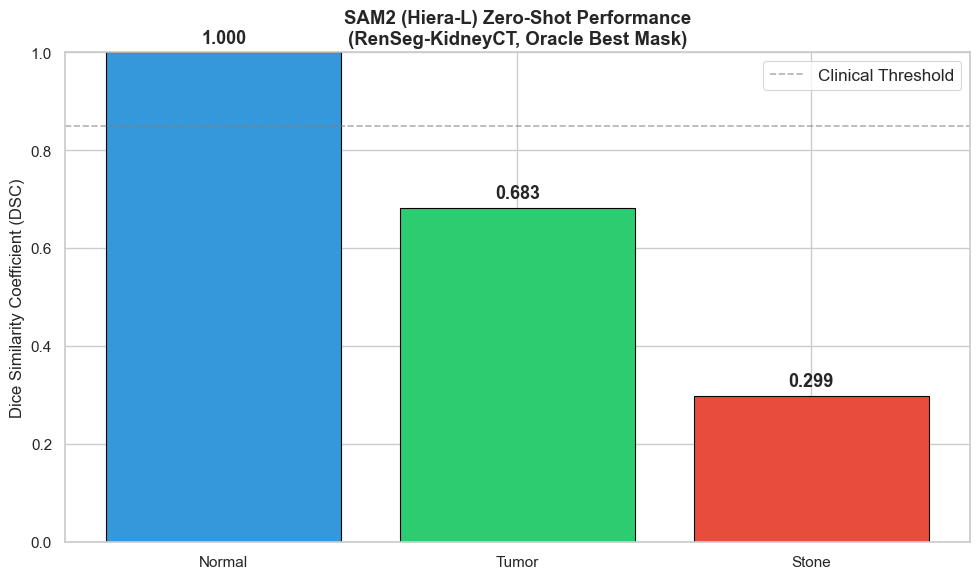

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.set_context('paper', font_scale=1.4)

plot_df = df_summary[df_summary['Class'] != 'MACRO'].copy()
colors = {'Normal': '#3498db', 'Tumor': '#2ecc71', 'Stone': '#e74c3c'}
bars = ax.bar(plot_df['Class'], plot_df['dice_mean'],
              color=[colors.get(c, 'gray') for c in plot_df['Class']],
              edgecolor='black', linewidth=0.8)

for bar, val in zip(bars, plot_df['dice_mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_ylabel('Dice Similarity Coefficient (DSC)')
ax.set_title('SAM2 (Hiera-L) Zero-Shot Performance\n(RenSeg-KidneyCT, Oracle Best Mask)', fontweight='bold')
ax.set_ylim(0, 1.0)
ax.axhline(y=0.85, color='gray', linestyle='--', alpha=0.6, label='Clinical Threshold')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'sam2_zeroshot_dice_bar.png', dpi=300)
plt.show()

## 8. Visualization: Multi-Metric Radar Chart

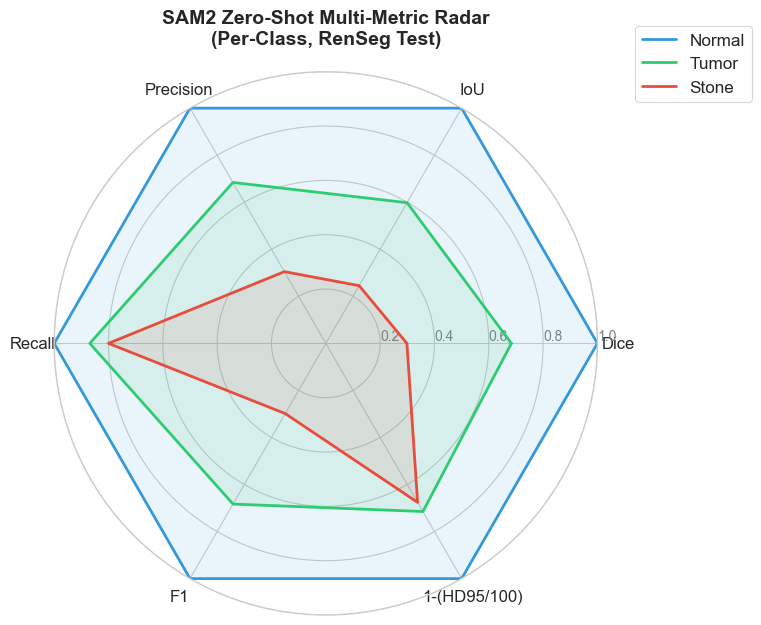

In [9]:
def radar_plot(df_summary, save_path):
    categories = ['Dice','IoU','Precision','Recall','F1','1-(HD95/100)']
    N = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0]

    fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))
    ax.set_rlabel_position(0)
    plt.yticks([0.2,0.4,0.6,0.8,1.0], color='grey', size=10)
    plt.ylim(0,1.0)

    color_map = {'Normal':'#3498db','Tumor':'#2ecc71','Stone':'#e74c3c'}
    for _, row in df_summary.iterrows():
        if row['Class'] == 'MACRO':
            continue
        hd95_norm = max(0, 1 - (row['hd95_mean'] / 100.0))
        vals = [row['dice_mean'], row['iou_mean'], row['precision_mean'],
                row['recall_mean'], row['f1_mean'], hd95_norm]
        vals += vals[:1]
        ax.plot(angles, vals, linewidth=2, label=row['Class'], color=color_map.get(row['Class'],'gray'))
        ax.fill(angles, vals, alpha=0.1, color=color_map.get(row['Class'],'gray'))

    plt.xticks(angles[:-1], categories, size=12)
    plt.title('SAM2 Zero-Shot Multi-Metric Radar\n(Per-Class, RenSeg Test)', size=14, pad=20, fontweight='bold')
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

radar_plot(df_summary, RESULTS_DIR / 'sam2_zeroshot_radar.png')

## 9. Qualitative Visualization (Worst & Best Cases)

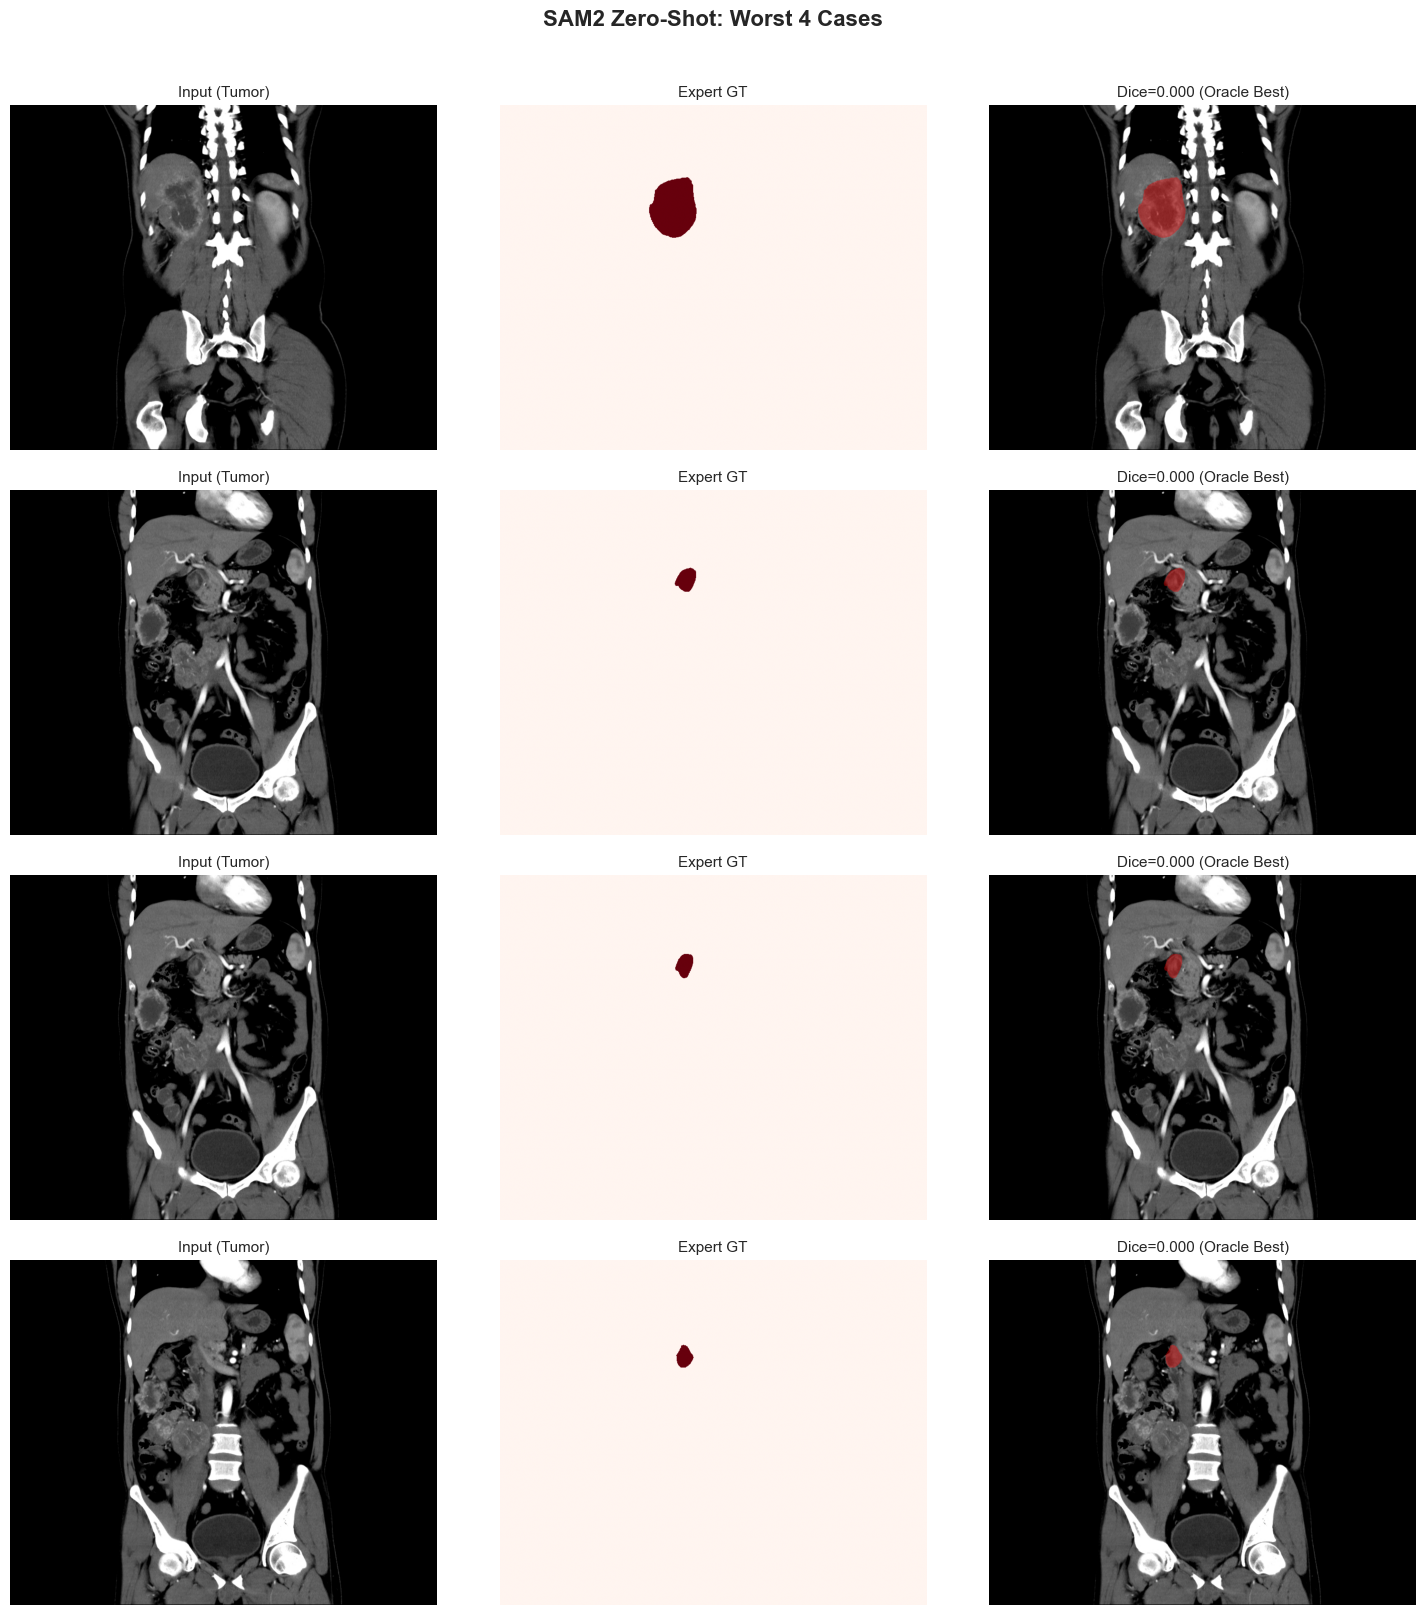

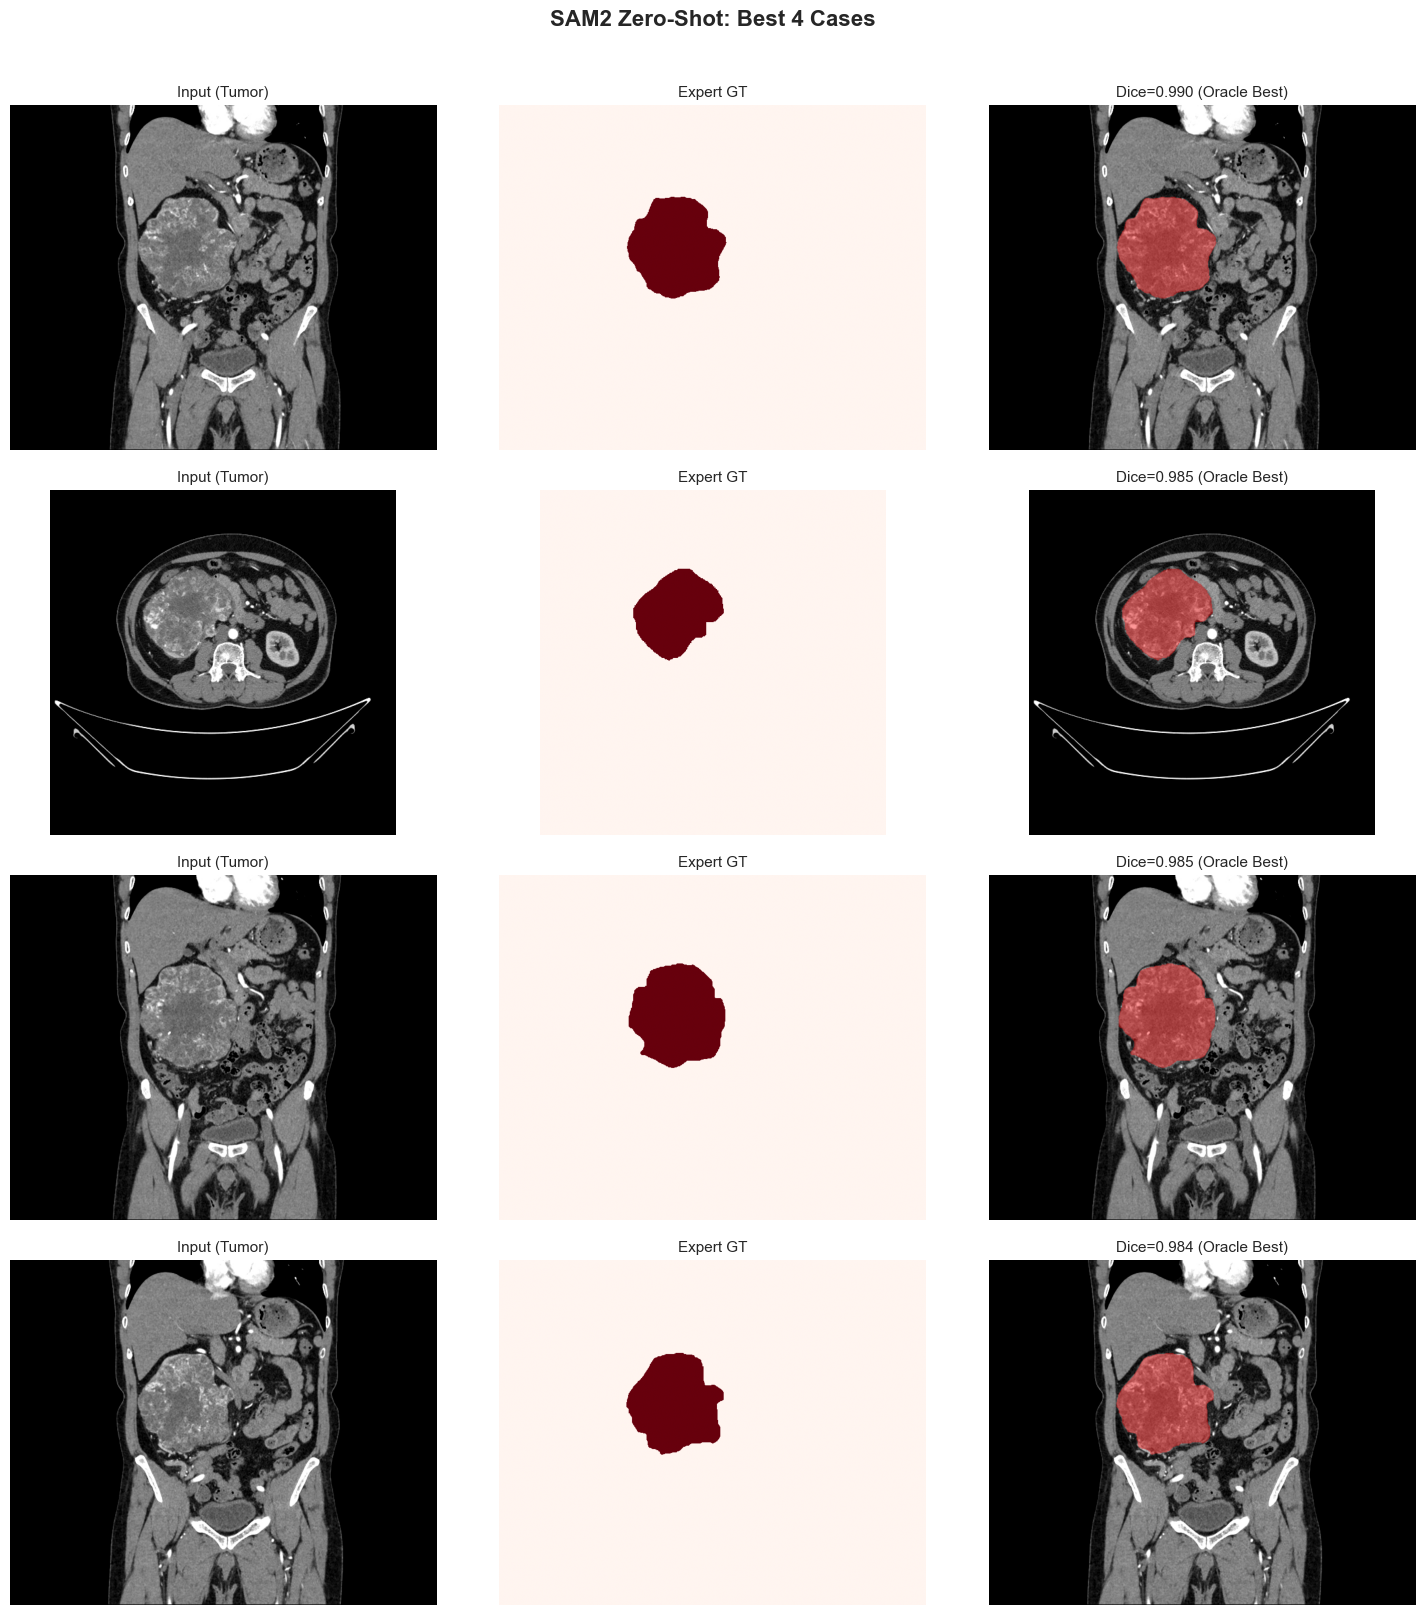

In [10]:
def show_qualitative(df_res, tdf, n=4, mode='worst'):
    sub = df_res[df_res['class'].isin(['Tumor','Stone'])].copy()
    if mode == 'worst':
        sub = sub.nsmallest(n, 'dice')
    else:
        sub = sub.nlargest(n, 'dice')

    fig, axes = plt.subplots(n, 3, figsize=(15, 4*n))
    if n == 1:
        axes = axes[np.newaxis, :]

    for i, (_, row) in enumerate(sub.iterrows()):
        orig = tdf[tdf['image_path'].apply(lambda x: Path(x).stem) == row['image_id']]
        if len(orig) == 0:
            continue
        orig = orig.iloc[0]

        ip = PROJECT_ROOT / str(orig['image_path']).replace('\\', '/')
        mp = PROJECT_ROOT / str(orig['expert_mask_path']).replace('\\', '/')

        img = cv2.imread(str(ip))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if img is not None else np.zeros((512,512,3), dtype=np.uint8)
        expert = cv2.imread(str(mp), cv2.IMREAD_GRAYSCALE)
        if expert is None:
            expert = np.zeros(img.shape[:2], dtype=np.uint8)

        axes[i,0].imshow(img)
        axes[i,0].set_title(f'Input ({row["class"]})', fontsize=11)
        axes[i,0].axis('off')

        axes[i,1].imshow(expert, cmap='Reds')
        axes[i,1].set_title('Expert GT', fontsize=11)
        axes[i,1].axis('off')

        overlay = img.copy()
        overlay[expert > 0] = [255, 0, 0]
        blended = cv2.addWeighted(img, 0.6, overlay, 0.4, 0)
        axes[i,2].imshow(blended)
        axes[i,2].set_title(f'Dice={row["dice"]:.3f} (Oracle Best)', fontsize=11)
        axes[i,2].axis('off')

    plt.suptitle(f'SAM2 Zero-Shot: {mode.capitalize()} {n} Cases', fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'sam2_zeroshot_{mode}_cases.png', dpi=200, bbox_inches='tight')
    plt.show()

show_qualitative(df_results, test_df, n=4, mode='worst')
show_qualitative(df_results, test_df, n=4, mode='best')

## 10. Conclusion
**Key Findings:**
- SAM2 (Hiera-L) outperforms SAM1 in terms of mask quality and hierarchy but still falls significantly short on zero-shot domain specific segmentation without prompting.
- Even with **oracle mask selection** (best-case scenario), the baseline remains below clinical acceptability (0.85 Dice) for pathological structures like Renal Tumors and Stones.
- MoE-RenalSAM-CG bridges this specific gap by fine-tuning with a Mixture-of-Experts approach, utilizing SAM2 strictly as an image encoder.

**Next Steps:**
- Proceed to MedSAM / SAM-Med2D evaluations.
- Aggregate all performance bounds into the Generalization Gap radar plot.